# Dot Products and Cosine Similarity

## Purpose

Understand the dot product as a way to measure alignment between vectors, and use it to project one vector onto another.

By the end of this notebook I should be able to:

- calculate dot products using NumPy
- explain the dot product as a measure of alignment
- recognise positive, zero and negative dot products geometrically
- explain why dot product size depends on both length and direction
- calculate the maximum and minimum possible dot product for fixed vector lengths
- normalise a dot product to get cosine similarity

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Helpers

In [2]:
def setup_vector_plot(xlim=(-1, 6), ylim=(-1, 5), figsize=(3, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    color=None,
    width=0.006
):
    origin = np.array(origin)
    v = np.array(v)

    ax.quiver(
        origin[0], origin[1],
        v[0], v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=width
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10
        )


def draw_dashed_line(ax, start, end):
    start = np.array(start)
    end = np.array(end)
    ax.plot([start[0], end[0]], [start[1], end[1]], linestyle="--")

## Quick recap: vectors and norms

In the previous notebook, vectors were represented as NumPy arrays and their length was calculated using the Euclidean norm.

In [3]:
a = np.array([3, 4])
np.linalg.norm(a)

np.float64(5.0)

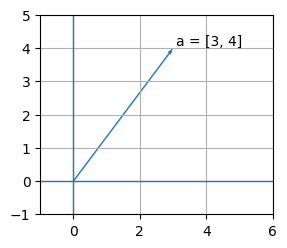

In [4]:
fig, ax = setup_vector_plot()
draw_vector(ax, a, label="a = [3, 4]")
plt.show()

## Dot product: the calculation

A dot product takes two vectors of the same length and produces a single number.

The calculation is simple:

1. multiply the matching values
2. add the results

For example, with:

$$
a = [3, 4]
\quad
b = [2, 1]
$$

The dot product is:

$$
a \cdot b = (3 \times 2) + (4 \times 1)
$$

$$
a \cdot b = 6 + 4 = 10
$$

So the dot product of $a = [3, 4]$ and $b = [2, 1]$ is **10**.

In [5]:
a = np.array([3, 4])
b = np.array([2, 1])

manual_dot = (3 * 2) + (4 * 1)
numpy_dot = np.dot(a, b)
dot_with_operator = a @ b

print("a:", a)
print("b:", b)
print("Manual dot product:", manual_dot)
print("NumPy dot product:", numpy_dot)
print("a @ b:", dot_with_operator)

a: [3 4]
b: [2 1]
Manual dot product: 10
NumPy dot product: 10
a @ b: 10


The manual calculation, `np.dot(a, b)`, and `a @ b` all give the same result.

For one-dimensional NumPy arrays, `a @ b` is a concise way to calculate the dot product.

### Developer note: `np.dot(a, b)` vs `a @ b`

For one-dimensional NumPy arrays, both of these calculate the dot product:

```python
np.dot(a, b)
a @ b
```

For the simple vector examples in this notebook, there is no meaningful performance difference. I can use the one that makes the code easiest to read.

There is a semantic difference once arrays become higher-dimensional:

np.dot(a, b) is NumPy’s older dot-product function
a @ b uses Python’s matrix multiplication operator
for 1D vectors, they behave like a dot product
for 2D arrays, a @ b means matrix multiplication
for higher-dimensional arrays, the rules differ in more subtle ways

In modern numerical Python, @ is often clearer when the operation is meant to represent linear algebra.

## Dot product as alignment

The dot product gives us a number, but that number has geometric meaning.

For two non-zero vectors:

- a positive dot product means they point broadly in the same direction
- a dot product of zero means they are at right angles
- a negative dot product means they point broadly in opposite directions

This makes the dot product useful as a rough measure of alignment.

In [6]:
reference = np.array([3, 1])

positive_alignment = np.array([1, 2])
orthogonal = np.array([-1, 3])
negative_alignment = np.array([-2, -1])

print("reference · positive_alignment:", reference @ positive_alignment)
print("reference · orthogonal:", reference @ orthogonal)
print("reference · negative_alignment:", reference @ negative_alignment)

reference · positive_alignment: 5
reference · orthogonal: 0
reference · negative_alignment: -7


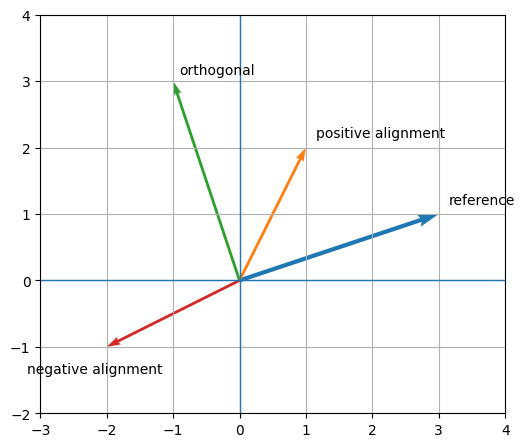

In [7]:
fig, ax = setup_vector_plot(
    xlim=(-3, 4),
    ylim=(-2, 4),
    figsize=(6, 6)
)

draw_vector(
    ax,
    reference,
    label="reference",
    label_offset=(0.15, 0.15),
    color="C0",
    width=0.009
)

draw_vector(
    ax,
    positive_alignment,
    label="positive alignment",
    label_offset=(0.15, 0.15),
    color="C1"
)

draw_vector(
    ax,
    orthogonal,
    label="orthogonal",
    label_offset=(0.1, 0.1),
    color="C2"
)

draw_vector(
    ax,
    negative_alignment,
    label="negative alignment",
    label_offset=(-1.2, -0.4),
    color="C3"
)

plt.show()

## Dot product size: alignment and length

The sign of the dot product tells us whether two vectors point broadly in the same or opposite directions.

The size of the dot product is affected by two things:

1. how aligned the vectors are
2. how long the vectors are

This means a large dot product can happen because vectors are well-aligned, because they are long, or both.

In [8]:
reference = np.array([3, 1])

small_aligned = np.array([1, 0])
larger_aligned = np.array([3, 1])
huge_aligned = np.array([9, 3])
less_aligned = np.array([0, 3])

print("reference · small_aligned:", reference @ small_aligned)
print("reference · larger_aligned:", reference @ larger_aligned)
print("reference · huge_aligned:", reference @ huge_aligned)
print("reference · less_aligned:", reference @ less_aligned)

reference · small_aligned: 3
reference · larger_aligned: 10
reference · huge_aligned: 30
reference · less_aligned: 3


`small_aligned` and `less_aligned` give the same dot product, even though they point in different directions.

That is because the dot product combines direction and length into a single number.

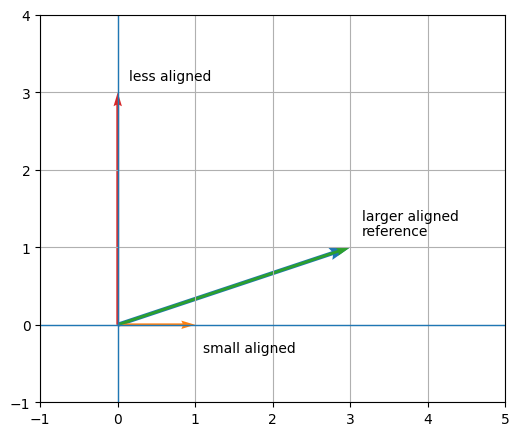

In [9]:
fig, ax = setup_vector_plot(
    xlim=(-1, 5),
    ylim=(-1, 4),
    figsize=(6, 6)
)

draw_vector(
    ax,
    reference,
    label="reference",
    label_offset=(0.15, 0.15),
    color="C0",
    width=0.009
)

draw_vector(
    ax,
    small_aligned,
    label="small aligned",
    label_offset=(0.1, -0.35),
    color="C1"
)

draw_vector(
    ax,
    larger_aligned,
    label="larger aligned",
    label_offset=(0.15, 0.35),
    color="C2"
)

draw_vector(
    ax,
    less_aligned,
    label="less aligned",
    label_offset=(0.15, 0.15),
    color="C3"
)

plt.show()

## Is there a maximum or minimum dot product?

If vector lengths are unrestricted, there is no fixed maximum or minimum dot product.

A vector can be made longer and longer in the same direction, making the dot product larger and larger.

However, for a fixed pair of vector lengths, there is a maximum and minimum possible dot product:

$$
-\|a\|\|b\| \le a \cdot b \le \|a\|\|b\|
$$

The maximum happens when the vectors point in the same direction.

The minimum happens when the vectors point in opposite directions.

This gives us a way to measure how close the actual dot product is to the largest possible dot product for vectors of those lengths.

## Normalised dot product: measuring direction only

The dot product combines direction and length.

If we divide the dot product by the product of the two vector lengths, we remove the effect of length:

$$
\frac{a \cdot b}{\|a\|\|b\|}
$$

This value is the cosine of the angle between the vectors:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\|\|b\|}
$$

The result is always between `-1` and `1`.

- `1` means same direction
- `0` means right angle
- `-1` means opposite direction

This is the basis of cosine similarity.

## Dot product, lengths and angles

The dot product can also be written in terms of vector lengths and the angle between the vectors:

$$
a \cdot b = \|a\| \|b\| \cos(\theta)
$$

This means:

$$
\text{dot product} =
\text{length of } a
\times
\text{length of } b
\times
\cos(\theta)
$$

The notation $\|a\|$ means “the length of vector $a$”.

For fixed vector lengths, the dot product is:

- largest when the vectors point in the same direction
- zero when the vectors are at right angles
- smallest when the vectors point in opposite directions

In [10]:
a = np.array([3, 1])
b = np.array([1, 2])

dot = a @ b
norm_product = np.linalg.norm(a) * np.linalg.norm(b)
cosine_similarity = dot / norm_product

print("a · b:", dot)
print("||a|| ||b||:", norm_product)
print("cosine similarity:", cosine_similarity)

a · b: 5
||a|| ||b||: 7.071067811865476
cosine similarity: 0.7071067811865475


In [11]:
angle_radians = np.arccos(cosine_similarity)
angle_degrees = np.degrees(angle_radians)

print("angle in degrees:", angle_degrees)

angle in degrees: 45.00000000000001


## Summary

The dot product combines two ideas:

1. **direction** — whether vectors point in similar, perpendicular or opposite directions
2. **length** — longer vectors can produce larger dot products

For fixed vector lengths:

$$
-\|a\|\|b\| \le a \cdot b \le \|a\|\|b\|
$$

Dividing by the product of the vector lengths gives cosine similarity:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\|\|b\|}
$$

Cosine similarity removes the effect of length and focuses on direction.

That makes it useful in machine learning when we care about whether two vectors point in similar directions, not just whether they are large.